In [1]:
# Session 3 setup: rebuild state from Session 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import get_stock_data
from plot_setup import setup_chinese_font

setup_chinese_font()

# Reload 平安银行 2024 with forward adjustment
df = pd.read_csv('data/sz000001_with_returns.csv', index_col='date', parse_dates=True)
print(df[['simple_return', 'log_return']].describe())

Chinese font set to: Microsoft YaHei
       simple_return  log_return
count     241.000000  241.000000
mean        0.001504    0.001369
std         0.016473    0.016359
min        -0.093168   -0.097798
25%        -0.007231   -0.007258
50%         0.000000    0.000000
75%         0.008780    0.008741
max         0.099796    0.095125


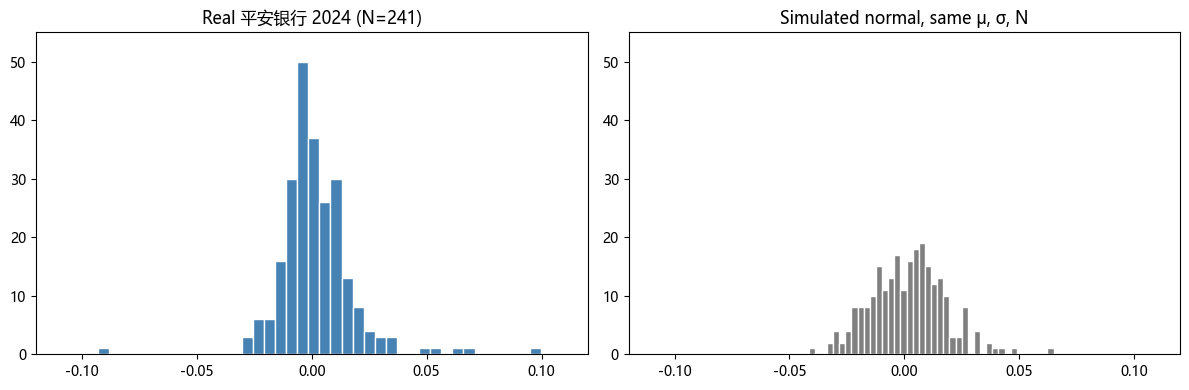

Real:      mean=0.0015, std=0.0165, skew=0.8582, kurt=10.6726
Simulated: mean=0.0014, std=0.0159, skew=0.3050, kurt=0.6651


In [2]:
# Simulate a normal distribution with parameters matched to 平安银行 2024
np.random.seed(42)  # reproducible — change the seed and the details change, but not the overall shape

real_returns = df['simple_return'].dropna()
mu = real_returns.mean()
sigma = real_returns.std()
n = len(real_returns)

simulated = np.random.normal(loc=mu, scale=sigma, size=n)

# Plot side by side with IDENTICAL axes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(real_returns, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title(f'Real 平安银行 2024 (N={n})')
axes[0].set_xlim(-0.12, 0.12)
axes[0].set_ylim(0, 55)

axes[1].hist(simulated, bins=40, color='gray', edgecolor='white')
axes[1].set_title(f'Simulated normal, same μ, σ, N')
axes[1].set_xlim(-0.12, 0.12)
axes[1].set_ylim(0, 55)

plt.tight_layout()
plt.show()

# And the numerical comparison
print(f"Real:      mean={real_returns.mean():.4f}, std={real_returns.std():.4f}, "
      f"skew={real_returns.skew():.4f}, kurt={real_returns.kurtosis():.4f}")
print(f"Simulated: mean={simulated.mean():.4f}, std={simulated.std():.4f}, "
      f"skew={pd.Series(simulated).skew():.4f}, kurt={pd.Series(simulated).kurtosis():.4f}")

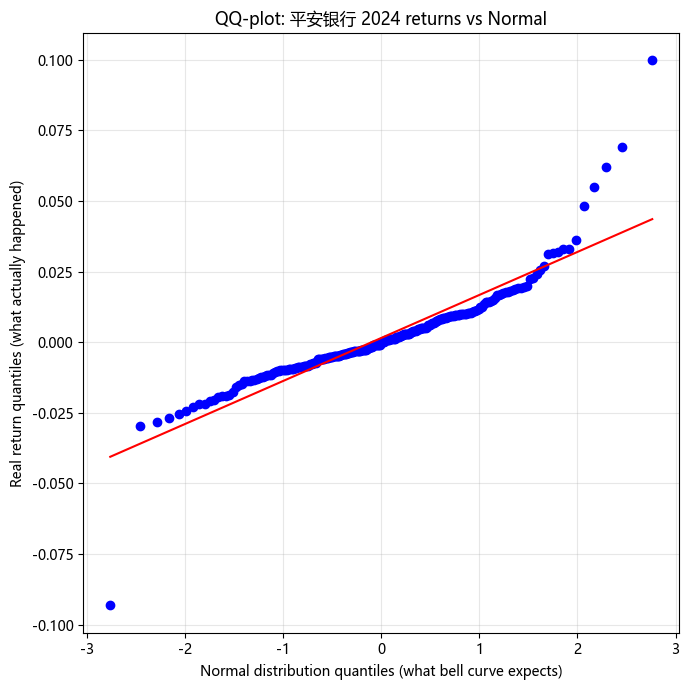

In [3]:
from scipy import stats

# QQ-plot of real 平安银行 2024 returns vs normal distribution
fig, ax = plt.subplots(figsize=(7, 7))

stats.probplot(real_returns, dist='norm', plot=ax)

ax.set_title('QQ-plot: 平安银行 2024 returns vs Normal')
ax.set_xlabel('Normal distribution quantiles (what bell curve expects)')
ax.set_ylabel('Real return quantiles (what actually happened)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

login success!
logout success!


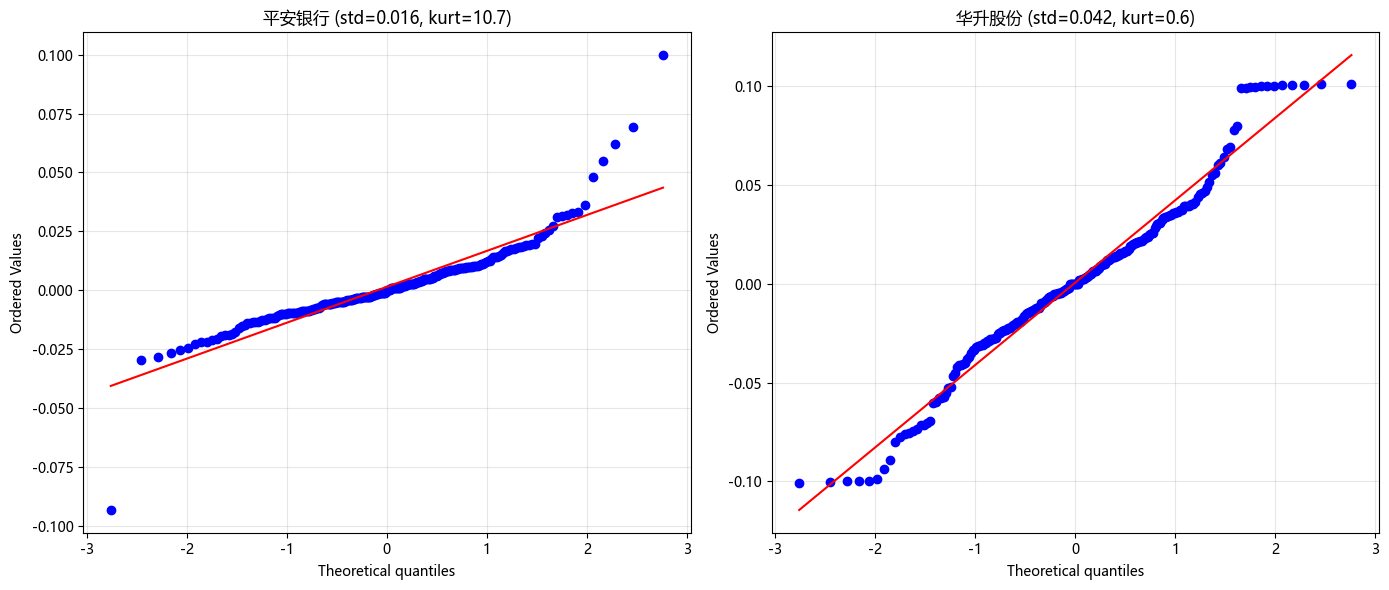

In [4]:
# Pull 华升股份 and compute returns
df_huasheng = get_stock_data('sh.600156', '2024-01-01', '2024-12-31', adjustflag='2')
df_huasheng['simple_return'] = df_huasheng['close'].pct_change()
huasheng_returns = df_huasheng['simple_return'].dropna()

# Two QQ-plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

stats.probplot(real_returns, dist='norm', plot=axes[0])
axes[0].set_title(f'平安银行 (std=0.016, kurt=10.7)')
axes[0].grid(True, alpha=0.3)

stats.probplot(huasheng_returns, dist='norm', plot=axes[1])
axes[1].set_title(f'华升股份 (std=0.042, kurt=0.6)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

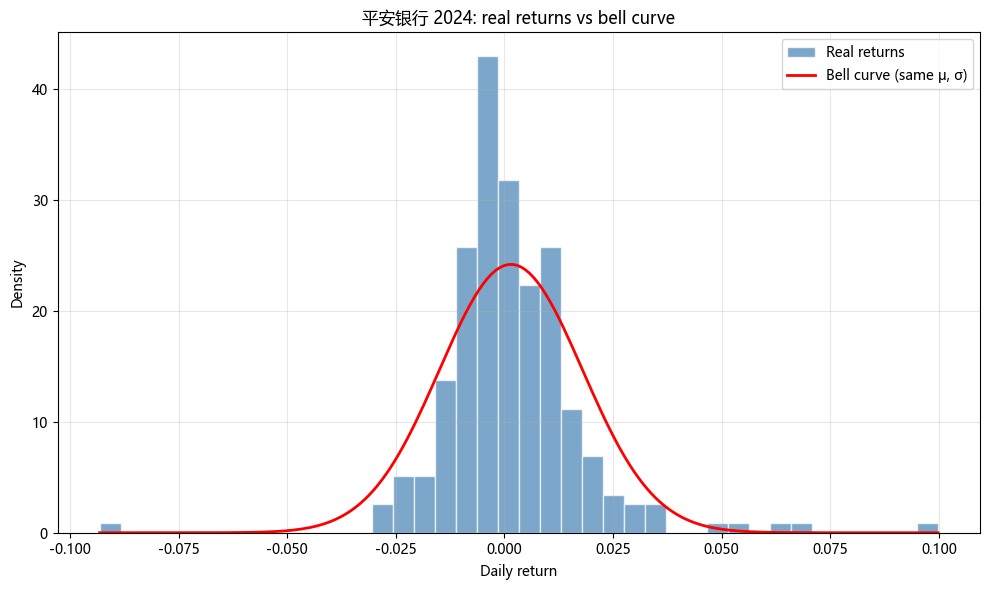

In [6]:
# Histogram with normal curve overlay: 平安银行 2024
fig, ax = plt.subplots(figsize=(10, 6))

# The real data as a histogram, normalized so it's a density (area sums to 1)
ax.hist(real_returns, bins=40, density=True, 
        color='steelblue', edgecolor='white', alpha=0.7, label='Real returns')

# The bell curve that would fit if returns were normal
x_range = np.linspace(real_returns.min(), real_returns.max(), 200)
bell_curve = stats.norm.pdf(x_range, loc=mu, scale=sigma)
ax.plot(x_range, bell_curve, color='red', linewidth=2, label='Bell curve (same μ, σ)')

ax.set_title('平安银行 2024: real returns vs bell curve')
ax.set_xlabel('Daily return')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()